# Who needs early help? Predicting long-term unemployment for UWV

Hackathon 5, Model Showdown · SDG 8 Decent Work and Economic Growth · De Haagse Hogeschool

When someone in the Netherlands loses their job and claims unemployment benefit (WW), UWV uses an algorithm, the *Werkverkenner*, to estimate their chance of being back at work within a year. People with a chance below 50% are invited for a face-to-face conversation with a work coach shortly after their benefit starts. Everyone else starts with online services and has a first conversation in the seventh month, unless a coach decides to invite them earlier (UWV, 2022; all sources are listed in the README).

This notebook builds a model for that same decision with Dutch panel data: the LISS panel (Centerdata, Tilburg University), which has followed the same people every month since November 2007. LISS records every month whether someone is working or looking for work, so we can see the moment someone loses their job and what happens in the twelve months after. Our question: *at the moment of job loss, can we predict who will still not be back in paid work twelve months later?*

We compare three scikit-learn classifiers (k-nearest neighbours, logistic regression and a random forest) against a dummy and two simple age rules, check whether the model makes the same mistakes for different groups, and end with a recommendation for UWV.

The notebook is also a check on the idea itself. How well can any model sort job seekers at intake, and is it realistic and fair to do it this way? Step 9c comes back to that.

The notebook follows the ten required steps in order. It runs from the raw LISS files, as downloaded from the LISS Data Archive, to the final prediction with *Restart & Run All*, locally or in Google Colab, without extra installs.

## About the data and privacy: why this notebook shows no individual people

This notebook uses data from the LISS panel. The people in the panel agreed to take part in scientific research, and everyone who downloads LISS data signs a statement that they will not pass the data on and will not publish information about individual persons or households. That has consequences for how this notebook is built.

The data is not in the repository. Anyone who wants to rerun the notebook has to request access to the LISS Data Archive themselves (see *Getting the data* below), and `data/liss/` is in `.gitignore` so it cannot be uploaded by accident.

The notebook never shows rows of data. There is no `head()`, no list of respondents and no example of a real person anywhere. Every table and chart shows counts, percentages, averages or model scores for groups, and a group with fewer than 10 people is shown as "< 10" without scores, so nobody can be recognised from a small cell. The job seeker in step 10 is made up.

LISS contains no names. People are identified by an encrypted number (`nomem_encr`), which we use to link the monthly files and surveys of the same person and to make sure one person never ends up in both the training and the test set. We never display it.

We also do not save the trained models. A KNN model stores every training row inside itself, so saving it would mean distributing the data.

Source: *LISS panel data, Centerdata (Tilburg University, The Netherlands)*. See the README for the full citation and the conditions of use.

In [1]:
import re
import sys
import zipfile
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sklearn

from sklearn.base import BaseEstimator, ClassifierMixin
from sklearn.model_selection import (StratifiedGroupKFold, GridSearchCV, cross_validate,
                                     cross_val_predict, cross_val_score)
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.dummy import DummyClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, balanced_accuracy_score, recall_score, precision_score, f1_score,
                             make_scorer, confusion_matrix, ConfusionMatrixDisplay)

RANDOM_STATE = 42   # used everywhere, so everyone gets the same numbers
MIN_GROUP = 10      # groups smaller than this are never shown separately (privacy, see above)
FIG_DIR = Path("docs") / "figures"   # the charts we also show in the README (group charts only, no data)
FIG_DIR.mkdir(parents=True, exist_ok=True)
pd.set_option("display.max_columns", 50)
pd.set_option("display.max_colwidth", None)
print("pandas", pd.__version__, "| numpy", np.__version__, "| scikit-learn", sklearn.__version__)

pandas 3.0.6 | numpy 2.5.3 | scikit-learn 1.9.1


## Getting the data

The LISS data cannot be downloaded by a script: you need your own account at the [LISS Data Archive](https://www.dataarchive.lissdata.nl/) and you have to sign the statement on the use of the data. Download these studies in **Stata format (.dta), English version**, and put the files (zipped or unzipped, file names do not matter) in these folders:

| Folder | LISS study | What we use it for |
|---|---|---|
| `data/liss/background/` | Background Variables, all monthly files, Nov 2007 to now | who works and who is looking for work each month; age, household, education, income |
| `data/liss/work_schooling/` | Core Study *Work and Schooling*, all waves | the job someone had before losing it |
| `data/liss/health/` | Core Study *Health*, all waves | health before losing the job |

**In Google Colab** the notebook mounts your Google Drive and reads the same folder structure from `MyDrive/liss/`. That folder is your own copy under the LISS conditions: do not share it.

The cell below unzips everything that is still zipped (once) and checks that all three folders contain data.

In [2]:
IN_COLAB = "google.colab" in sys.modules
if IN_COLAB:
    from google.colab import drive
    drive.mount("/content/drive")
    LISS_DIR = Path("/content/drive/MyDrive/liss")
else:
    LISS_DIR = Path("data") / "liss"

STUDIES = ["background", "work_schooling", "health"]

def unzip_all(folder):
    # Extract every zip (also zips inside zips) into a folder next to it, only the first time.
    done = set()
    while True:
        zips = [z for z in folder.rglob("*.zip") if z not in done and "__MACOSX" not in z.parts]
        if not zips:
            return
        for z in zips:
            if not z.with_suffix("").exists():
                with zipfile.ZipFile(z) as zf:
                    zf.extractall(z.with_suffix(""))
            done.add(z)

def dta_files(folder):
    # All .dta files in a folder, each file name once (a file can be both zipped and unzipped).
    files = {}
    for p in sorted(folder.rglob("*.dta")):
        if not p.name.startswith("._") and "__MACOSX" not in p.parts:
            files.setdefault(p.name, p)
    return list(files.values())

files = {}
for study in STUDIES:
    folder = LISS_DIR / study
    assert folder.exists(), f"Folder {folder} not found - see 'Getting the data' above."
    unzip_all(folder)
    files[study] = dta_files(folder)
    assert files[study], f"No .dta files in {folder} - download the Stata version."
    print(f"{study:15s} {len(files[study]):4d} .dta files")

background       220 .dta files
work_schooling    18 .dta files
health            18 .dta files


In [3]:
def stata_columns(path):
    with pd.read_stata(path, iterator=True, convert_categoricals=False) as reader:
        return list(reader.variable_labels())

def read_dta(path, wanted):
    # Read only the columns we need; LISS answer codes are kept as numbers (labels come from the codebook).
    present = {c.lower(): c for c in stata_columns(path)}
    cols = [present[w] for w in wanted if w in present]
    df = pd.read_stata(path, columns=cols, convert_categoricals=False)
    df.columns = [c.lower() for c in df.columns]
    return df

def month_index(yyyymm):
    # 200711 -> a running month number, so that "the month after" is simply +1
    yyyymm = pd.Series(yyyymm).astype("int64")
    return (yyyymm // 100) * 12 + yyyymm % 100 - 1

# Background Variables: one file per month, one row per panel member
AVARS = ["nomem_encr", "wave", "belbezig", "leeftijd", "geslacht", "oplmet", "aantalhh", "aantalki",
         "partner", "woonvorm", "sted", "nettoink_f", "herkomstgroep"]
frames = []
for f in files["background"]:
    df = read_dta(f, AVARS)
    if "wave" not in df.columns:                      # fallback: month from the file name
        df["wave"] = int(re.search(r"(20\d{2})(0[1-9]|1[0-2])", f.name).group(0))
    frames.append(df)
panel = pd.concat(frames, ignore_index=True).dropna(subset=["nomem_encr", "wave", "belbezig"])
panel["nomem_encr"] = panel["nomem_encr"].astype("int64")
panel["t"] = month_index(panel["wave"]).to_numpy()
panel = panel.drop_duplicates(["nomem_encr", "t"]).sort_values(["nomem_encr", "t"]).reset_index(drop=True)

def read_core(study, questions):
    # Core studies have one file per wave; variable names are <prefix><question number>, e.g. cw08a121.
    # The question numbers and answer codes are the same in every wave (checked in docs/liss_overview.md).
    out = []
    for f in files[study]:
        cols = [c.lower() for c in stata_columns(f)]
        prefix = pd.Series([m.group(1) for c in cols if (m := re.match(r"^([a-z]{2}\d{2}[a-z])\d{3}$", c))]).mode()[0]
        names = {"nomem_encr": "nomem_encr", f"{prefix}_m": "interview_month"}
        names.update({f"{prefix}{q}": name for q, name in questions.items()})
        df = read_dta(f, list(names)).rename(columns=names)
        df["wave"] = prefix
        out.append(df)
    core = pd.concat(out, ignore_index=True).dropna(subset=["nomem_encr", "interview_month"])
    core["nomem_encr"] = core["nomem_encr"].astype("int64")
    core["t_interview"] = month_index(core["interview_month"]).to_numpy()
    return core.drop(columns="interview_month")

work = read_core("work_schooling", {"121": "contract_code", "122": "organisation_code", "126": "contract_hours_raw",
                                     "134": "employer_since", "402": "sector_code", "404": "occupation_code",
                                     "409": "supervisor_code", "408": "firm_size_408", "528": "firm_size_528"})
health = read_core("health", {"004": "health_self_rated_raw", "018": "longstanding_disease_code",
                              "020": "health_hinders_raw"})

def month_text(t):
    return f"{t // 12}-{t % 12 + 1:02d}"

overview = pd.DataFrame([
    {"study": "Background Variables", "files / waves": len(files["background"]),
     "period": f"{month_text(panel.t.min())} to {month_text(panel.t.max())}",
     "rows": len(panel), "different persons": panel.nomem_encr.nunique()},
    {"study": "Work and Schooling", "files / waves": work.wave.nunique(),
     "period": f"{month_text(work.t_interview.min())} to {month_text(work.t_interview.max())}",
     "rows": len(work), "different persons": work.nomem_encr.nunique()},
    {"study": "Health", "files / waves": health.wave.nunique(),
     "period": f"{month_text(health.t_interview.min())} to {month_text(health.t_interview.max())}",
     "rows": len(health), "different persons": health.nomem_encr.nunique()},
]).set_index("study")
overview

,files / waves,period,rows,different persons
study,,,,
Background Variables,220,2007-11 to 2026-03,2424987,34301
Work and Schooling,18,2008-04 to 2025-05,104288,18188
Health,18,2007-11 to 2025-12,101691,17699


## Step 1: Frame the problem

**Decision and user.** The user is the UWV work coach who handles new WW claimants. The decision is: invite this person early for a face-to-face conversation, yes or no. UWV does not see everyone in the first month, so someone has to choose.

**Who the prediction is about.** People aged 18 to 66 in the Netherlands who have just lost their job. In LISS these are panel members who move from paid work (employee, family business or self-employed) in one month to *job seeker following job loss* in the next.

**Target and positive class.** `long_term` = 1 if the person is not back in paid work in any of the eleven months after the first month of job seeking. In other words, their spell without work lasts twelve months or more. This is the person who most needs early help. People who left the panel before we could see month twelve are left out, because their outcome is unknown.

**Which mistake is worse?** A false negative is a person who will be without work for a year or more, but is predicted to find work quickly. They are not invited early and lose months without help while their benefit runs down. UWV's own evaluation found that personal help raises the share of people in work by about 2 percentage points, so missing someone costs them real chances. A false positive is a person who would have found work anyway but is invited early. That costs one conversation of a work coach's time. So a false negative is worse.

**Main metric: balanced accuracy.** Recall alone would reward a model that simply invites everyone (recall 1.0), which UWV cannot afford and which is the same as having no model. Accuracy is misleading because the classes are not equal in size. Most people do find work within a year, so a model that predicts "back in work" for everyone already looks good on accuracy while it never finds anyone who needs help. Balanced accuracy is the average of the recall for the long-term group and the recall for the short-term group, so "invite everyone" and "invite nobody" both score 0.5. It forces a model to find the long-term group and also not invite people who would manage on their own.

We compare and tune all models on balanced accuracy and always report recall and precision next to it. In step 9 we lower the decision threshold on purpose so that recall for the long-term group goes up, because a missed person is the more costly mistake.

## Step 2: Explore the data

### 2a. What is in the raw files?
Each monthly Background Variables file has one row per panel member with their **primary occupation** that month (`belbezig`). This is the variable that lets us see job loss happen. Over all months together:

In [4]:
BELBEZIG = {1: "paid employment", 2: "works or assists in family business", 3: "self-employed / freelancer",
            4: "job seeker following job loss", 5: "first-time job seeker",
            6: "exempted from job seeking following job loss", 7: "attends school or is studying",
            8: "takes care of the housekeeping", 9: "pensioner", 10: "(partial) work disability",
            11: "unpaid work while retaining unemployment benefit", 12: "voluntary work",
            13: "something else", 14: "too young to have an occupation"}
occupation_counts = panel["belbezig"].value_counts().sort_index()
pd.DataFrame({"primary occupation": occupation_counts.index.map(BELBEZIG),
              "person-months": occupation_counts.to_numpy()}, index=occupation_counts.index.astype(int))

,primary occupation,person-months
belbezig,,
1,paid employment,951941
2,works or assists in family business,25030
3,self-employed / freelancer,123167
4,job seeker following job loss,38618
5,first-time job seeker,7626
6,exempted from job seeking following job loss,5902
7,attends school or is studying,513247
8,takes care of the housekeeping,150391
9,pensioner,372435


### 2b. Who do we predict for? Finding job losses in the monthly data
A **job loss** is the first month someone is a *job seeker following job loss* (code 4) directly after a month in paid work (codes 1-3). For each job loss we look at the eleven months after it:
- back in paid work (1-3) in any of those months → `long_term` = 0;
- not back in paid work, and still in the panel eleven months later → `long_term` = 1 (most are still looking for work; a few moved to studying, disability, housekeeping or retirement, so they did not get back to work either);
- left the panel before that → outcome unknown, **dropped**.

Defining the population is not cleaning, so it happens before the split. Note that one person can lose a job more than once in 18 years: those are separate rows, which matters for the split in step 3.

In [5]:
WORK = [1, 2, 3]                 # paid employment, family business, self-employed
UNEMPLOYED = [4, 5, 6, 11]       # looking for work / exempted / unpaid work with benefit

# Look-up table: for a person and a month, what was their main activity? (NaN if they did not answer that month)
status = panel.set_index(["nomem_encr", "t"])["belbezig"]
def status_at(ids, months):
    return status.reindex(pd.MultiIndex.from_arrays([ids, months])).to_numpy()

# A job loss: job seeker this month, paid work in the row before, and that row is exactly one month earlier
previous = panel.groupby("nomem_encr")[["t", "belbezig"]].shift()
is_job_loss = (panel["belbezig"] == 4) & previous["belbezig"].isin(WORK) & (panel["t"] - previous["t"] == 1)
spells = panel.loc[is_job_loss, ["nomem_encr", "t"]].rename(columns={"t": "t_start"}).reset_index(drop=True)

# The eleven months after the job loss, one column per month
after = np.column_stack([status_at(spells.nomem_encr, spells.t_start + k) for k in range(1, 12)])
back_in_work = np.isin(after, WORK).any(axis=1)
last_seen = spells["nomem_encr"].map(panel.groupby("nomem_encr")["t"].max()).to_numpy()
seen_month_12 = last_seen >= spells["t_start"].to_numpy() + 11
spells["outcome"] = np.select([back_in_work, seen_month_12],
                              ["back in work within 12 months", "not back in work after 12 months"],
                              default="unknown (left the panel or too recent)")

# characteristics in the last month in work (the month before the job loss)
last_job_month = panel.set_index(["nomem_encr", "t"]).reindex(
    pd.MultiIndex.from_arrays([spells.nomem_encr, spells.t_start - 1])).reset_index(drop=True)
spells = pd.concat([spells, last_job_month.drop(columns=["wave", "belbezig"])], axis=1)

funnel = [("Job losses found in the monthly data, Nov 2007 - now", len(spells))]
spells = spells[spells["outcome"] != "unknown (left the panel or too recent)"]
funnel.append(("... with a known outcome 12 months later", len(spells)))
spells = spells[spells["leeftijd"].between(18, 66)].reset_index(drop=True)
funnel.append(("... and aged 18-66 at job loss", len(spells)))

y = (spells["outcome"] == "not back in work after 12 months").astype(int).rename("long_term")
groups = spells["nomem_encr"]      # person number: only used to keep each person in one part of the split
display(pd.DataFrame(funnel, columns=["filter", "rows"]))
print(f"Different persons: {groups.nunique():,} (some lost a job more than once)")
print(f"Class balance: {y.mean():.1%} not back in work after 12 months (1), {1 - y.mean():.1%} back within 12 months (0)")

,filter,rows
0,"Job losses found in the monthly data, Nov 2007 - now",2126
1,... with a known outcome 12 months later,2023
2,... and aged 18-66 at job loss,2019


Different persons: 1,455 (some lost a job more than once)
Class balance: 39.1% not back in work after 12 months (1), 60.9% back within 12 months (0)


### 2c. Features: only what is known at the moment of job loss
UWV has to decide at intake, so every feature must be known **before** the job loss. We take:
- **Background Variables** from the last month in work (age, gender, education, household, urbanity, net income).
- **Work history from the monthly panel:** the number of months someone was looking for work in the 36 months before, and how many of those 36 months we can see (people who recently joined the panel have a shorter visible history, and without this second column the model could not tell "never unemployed" from "not yet in the panel").
- **Work and Schooling:** the most recent interview *before* the job loss, at most 24 months earlier: contract, organisation type, hours, years with the employer, sector, occupation, supervising others and firm size. These describe the job that was lost (or, if the person changed jobs in between, the job before).
- **Health:** the most recent interview *before* the job loss, at most 24 months earlier: self-rated health, a long-standing disease, and how much health hinders daily activities.

LISS stores answers as numbers. Below we translate them with the codebook, and turn codes that mean *don't know*, *prefer not to say* or an impossible value (an employment start year in the future, a working week of 0 or more than 80 hours) into proper missing values (`NaN`). These are row-by-row translations and nothing is learned from the data, so they are safe to do before the split. We count how many values each rule changed.

In [6]:
spells["spell_id"] = np.arange(len(spells))

def last_interview_before(interviews, max_months=24):
    # For every job loss: the person's most recent interview strictly before the job-loss month.
    left = spells[["spell_id", "nomem_encr", "t_start"]].sort_values("t_start")
    right = interviews.sort_values("t_interview")
    # merge_asof looks backwards in time per person: the last interview before t_start, not the month itself
    # (allow_exact_matches=False) and at most max_months earlier (tolerance). No interview in that window = NaN.
    merged = pd.merge_asof(left, right, left_on="t_start", right_on="t_interview", by="nomem_encr",
                           direction="backward", allow_exact_matches=False, tolerance=max_months)
    return merged.set_index("spell_id").sort_index()

job = last_interview_before(work)
hlth = last_interview_before(health)

# Main activity in each of the 36 months before the job loss (one column per month, NaN = not in the panel yet)
history = np.column_stack([status_at(spells.nomem_encr, spells.t_start - k) for k in range(1, 37)])

# Migration background never changes, but it was only recorded from October 2010: take each person's own value.
origin_code = (panel.loc[panel.nomem_encr.isin(groups), ["nomem_encr", "herkomstgroep"]].dropna()
               .groupby("nomem_encr")["herkomstgroep"].agg(lambda s: s.mode().iloc[0]))

In [7]:
impossible = {}
def valid(series, low, high, name):
    # Keep values in [low, high]; everything else (negative codes, 999999, impossible values) becomes NaN.
    bad = series.notna() & ~series.between(low, high)
    impossible[name] = int(bad.sum())
    return series.where(~bad)

def labels(series, mapping):
    # Translate codes into readable labels; codes not in the mapping become NaN.
    return series.map(mapping)

start_year = spells["t_start"] // 12
data = pd.DataFrame(index=spells.index)
data["age"] = spells["leeftijd"]
data["household_size"] = valid(spells["aantalhh"], 1, 20, "household size")
data["children_at_home"] = valid(spells["aantalki"], 0, 15, "children at home")
data["net_income"] = valid(spells["nettoink_f"], 0, 15000, "net monthly income (EUR)")
data["months_unemployed_before"] = np.isin(history, UNEMPLOYED).sum(axis=1)
data["months_in_panel_before"] = (~np.isnan(history)).sum(axis=1)
data["contract_hours"] = valid(job["contract_hours_raw"], 1, 80, "contract hours per week")
data["years_with_employer"] = valid(start_year - valid(job["employer_since"], 1940, 2030, "employer start year"),
                                    0, 60, "years with employer")
data["health_self_rated"] = valid(hlth["health_self_rated_raw"], 1, 5, "self-rated health")       # 1 poor .. 5 excellent
data["health_hinders"] = valid(hlth["health_hinders_raw"], 1, 5, "health hinders daily activities")  # 1 not at all .. 5 very much

data["gender"] = labels(spells["geslacht"], {1: "male", 2: "female", 3: "other"})
data["education"] = labels(spells["oplmet"], {1: "primary", 2: "vmbo", 3: "havo/vwo", 4: "mbo", 5: "hbo", 6: "wo",
                                               7: "other", 8: "none completed", 9: "none completed"})
data["partner"] = labels(spells["partner"], {0: "no", 1: "yes"})
data["domestic_situation"] = labels(spells["woonvorm"], {1: "single", 2: "couple, no children", 3: "couple with children",
                                                          4: "single parent", 5: "other"})
data["urbanity"] = labels(spells["sted"], {1: "extremely urban", 2: "very urban", 3: "moderately urban",
                                           4: "slightly urban", 5: "not urban"})
data["contract"] = labels(job["contract_code"], {1: "permanent", 2: "temporary", 3: "on-call", 4: "temp agency",
                                                 5: "self-employed", 6: "self-employed", 7: "director / owner",
                                                 8: "director / owner"})
data["organisation"] = labels(job["organisation_code"], {1: "public", 2: "private"})
data["sector"] = labels(job["sector_code"], {
    1: "agriculture", 2: "mining", 3: "industry", 4: "utilities", 5: "construction", 6: "retail", 7: "catering",
    8: "transport and communication", 9: "financial", 10: "business services", 11: "public administration",
    12: "education", 13: "healthcare and welfare", 14: "culture and other services", 15: "other"})
data["occupation"] = labels(job["occupation_code"], {
    1: "higher academic / independent", 2: "higher supervisory", 3: "intermediate academic / independent",
    4: "intermediate supervisory / commercial", 5: "other mental work (administrative, sales)",
    6: "skilled manual", 7: "semi-skilled manual", 8: "unskilled manual", 9: "agrarian"})
data["supervisor"] = labels(job["supervisor_code"], {1: "yes", 2: "no"})
firm_size = valid(job["firm_size_408"].fillna(job["firm_size_528"]), 1, 500000, "firm size")
data["firm_size"] = pd.cut(firm_size, [0, 9, 49, 249, np.inf], labels=["1-9", "10-49", "50-249", "250+"]).astype("object")
data["longstanding_disease"] = labels(hlth["longstanding_disease_code"], {1: "yes", 2: "no"})

# Columns used only to check fairness - never as a model feature (see 2f and step 8)
ORIGIN = {0: "Dutch background", 101: "first generation migrant", 102: "first generation migrant",
          201: "second generation migrant", 202: "second generation migrant"}
info = pd.DataFrame(index=data.index)
info["age band"] = pd.cut(data["age"], [17, 29, 49, 66], labels=["18-29", "30-49", "50-66"]).astype("object")
info["gender"] = data["gender"]
info["education"] = labels(spells["oplmet"], {1: "low", 2: "low", 8: "low", 9: "low", 3: "middle", 4: "middle",
                                              5: "high", 6: "high", 7: "other"})
info["origin"] = spells["nomem_encr"].map(origin_code).map(ORIGIN)
info["long-standing disease"] = data["longstanding_disease"]

print("Values set to missing because they were a code or impossible:")
pd.Series(impossible, name="values").to_frame()

Values set to missing because they were a code or impossible:


,values
household size,0
children at home,0
net monthly income (EUR),1
contract hours per week,32
employer start year,0
years with employer,0
self-rated health,0
health hinders daily activities,0
firm size,204


In [8]:
missing = data.isna().mean().mul(100).round(1).sort_values(ascending=False)
print(f"Job losses with a Work and Schooling interview in the 24 months before: {job['wave'].notna().mean():.0%}")
print(f"Job losses with a Health interview in the 24 months before:              {hlth['wave'].notna().mean():.0%}")
missing.to_frame("% missing")

Job losses with a Work and Schooling interview in the 24 months before: 72%
Job losses with a Health interview in the 24 months before:              70%


,% missing
firm_size,43.5
years_with_employer,40.2
contract_hours,36.1
organisation,33.3
supervisor,32.3
sector,31.8
contract,30.6
health_hinders,30.4
longstanding_disease,30.2
health_self_rated,30.1


The job and health columns are missing for everyone who did not take part in that year's Work and Schooling or Health survey in the 24 months before their job loss. We keep these people: in the pipeline a missing category answer becomes its own category *missing*, and a missing number gets the training median **plus a 0/1 column that says it was missing**, so the model can learn whether "no survey answer" itself says something. Net income is missing for job losses before July 2008 (the imputed income variable starts then).

### 2d. Duplicates

In [9]:
print("Same job loss twice (person + month):", spells.duplicated(subset=["nomem_encr", "t_start"]).sum())
spells_per_person = groups.value_counts()
print("Persons with 1 job loss:", (spells_per_person == 1).sum(), "| with 2 or more:", (spells_per_person >= 2).sum())
identical = data.duplicated(keep=False)
print("Rows with exactly the same feature values:", data.duplicated().sum(),
      "| of which the same person:", int(identical.any() and groups[identical].duplicated().sum()))

Same job loss twice (person + month): 0
Persons with 1 job loss: 1103 | with 2 or more: 352
Rows with exactly the same feature values: 1 | of which the same person: 1


No job loss appears twice. One pair of job losses has exactly the same feature values; the line above shows whether it is the same person (then the split keeps both on one side). But **the same person can appear with several job losses**, years apart. If one of their job losses landed in the training set and another in the test set, the model could partly *recognise the person* (same gender, education, origin, similar household) instead of predicting for a new one. That is a hidden form of leakage, so in step 3 we split **by person**: all job losses of one person go to the same side.

### 2e. Columns that leak the answer
Some information is only known *after* the outcome, or is a *consequence* of a long spell without work. We avoid these on purpose, by construction:

| Not used | Why |
|---|---|
| `belbezig` and everything else from the months **after** the job loss | this *is* the outcome (or a direct consequence of it) |
| Work and Schooling / Health interviews **after** the job loss | answers about job seeking, income and health after the job loss describe the spell itself, e.g. a person who is depressed after ten months without work |
| Income after the job loss, benefits received (Core Study *Income*) | consequences of the job loss; WW receipt is only asked per calendar year, so it mixes months before and after |
| Calendar year of the job loss | known at intake, but a model that learned "2013 was a bad year" cannot be used for future years |
| `nomem_encr` (person number) | an identifier, not a characteristic; only used for the split |
| Migration background (`herkomstgroep`) | kept *out* of the model on purpose; used only to check fairness (step 8) |

### 2f. Distributions: who is still without work after a year?

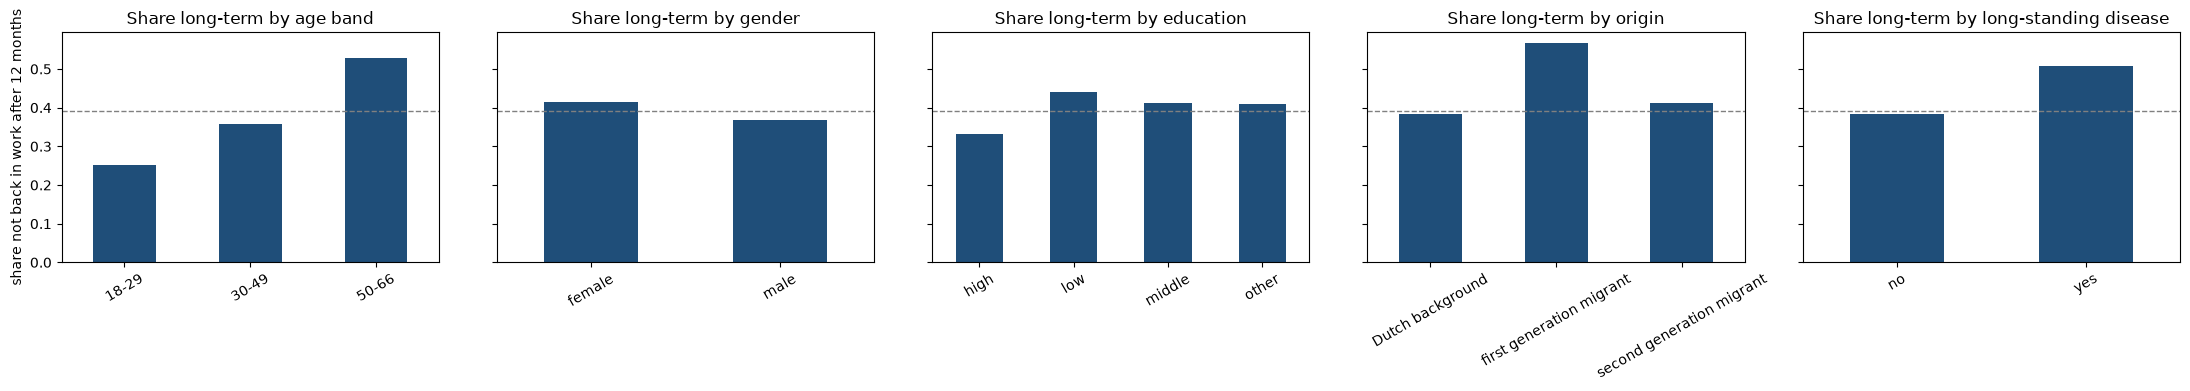

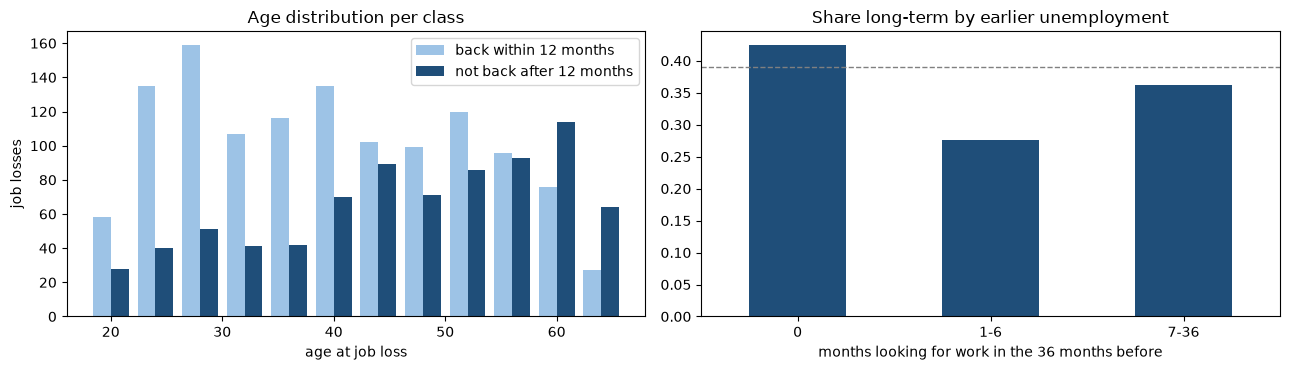

In [10]:
def share_by(group_col, frame=info, target=y):
    # Share long-term per group; groups with fewer than MIN_GROUP people are not shown.
    g = pd.DataFrame({"group": frame[group_col], "y": target}).dropna().groupby("group")["y"].agg(["size", "mean"])
    return g[g["size"] >= MIN_GROUP]["mean"]

fig, axes = plt.subplots(1, 5, figsize=(22, 4), sharey=True)
for ax, col in zip(axes, info.columns):
    share_by(col).plot.bar(ax=ax, color="#1f4e79")
    ax.axhline(y.mean(), color="grey", linestyle="--", linewidth=1)
    ax.set_title(f"Share long-term by {col}")
    ax.set_xlabel("")
    ax.tick_params(axis="x", rotation=30)
axes[0].set_ylabel("share not back in work after 12 months")
plt.tight_layout()
plt.savefig(FIG_DIR / "share_long_term_by_group.png", dpi=120, bbox_inches="tight")
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(13, 3.8))
axes[0].hist([data.loc[y == 0, "age"], data.loc[y == 1, "age"]], bins=range(18, 68, 4),
             label=["back within 12 months", "not back after 12 months"], color=["#9dc3e6", "#1f4e79"])
axes[0].set_xlabel("age at job loss"); axes[0].set_ylabel("job losses"); axes[0].legend()
axes[0].set_title("Age distribution per class")
history_band = pd.cut(data["months_unemployed_before"], [-1, 0, 6, 36], labels=["0", "1-6", "7-36"]).astype("object")
share_by("history", pd.DataFrame({"history": history_band})).plot.bar(ax=axes[1], color="#1f4e79")
axes[1].axhline(y.mean(), color="grey", linestyle="--", linewidth=1)
axes[1].set_xlabel("months looking for work in the 36 months before"); axes[1].tick_params(axis="x", rotation=0)
axes[1].set_title("Share long-term by earlier unemployment")
plt.tight_layout()
plt.show()

**What the bars show.** The dashed line is the overall share, 39%.

Age matters most. Of the 18-29-year-olds 25% are still without work after a year, of the 30-49-year-olds 36% and of the 50-66-year-olds 53%. In the histogram the dark bars overtake the light ones from about age 55. This matches what CPB (2015) found for the Netherlands: older people do not lose their job more often, but once they do, they are much more likely to stay unemployed for more than a year.

People who migrated to the Netherlands themselves (first generation) are clearly more often long-term unemployed (57%) than people with a Dutch background (38%). The second generation is close to average (41%). A long-standing disease before the job loss raises the share from 38% to 51%. Higher-educated people are less often long-term (33%) than lower-educated people (44%), and women (41%) slightly more often than men (37%).

Earlier unemployment does not work the way we expected. People who were not looking for work at all in the three years before are more often long-term (42%) than people with 1 to 6 months of job seeking (28%). A possible explanation is that people who lose a long, stable job have more trouble finding a new one than people who move between short jobs anyway. We did not test this.

## Step 3: Split first
We set aside 20% of the rows as a test set **before** any imputing, scaling or tuning. The split is stratified (both parts have the same share of long-term cases), uses a fixed `random_state`, and is **grouped by person** (`StratifiedGroupKFold`): every job loss of one person ends up on the same side, as explained in 2d. We take one of five folds as the test set, which gives 20%. The test set is used exactly once, in step 7.

In [11]:
NUMERIC = ["age", "household_size", "children_at_home", "net_income", "months_unemployed_before",
           "months_in_panel_before", "contract_hours", "years_with_employer", "health_self_rated", "health_hinders"]
CATEGORICAL = ["gender", "education", "partner", "domestic_situation", "urbanity", "contract", "organisation",
               "sector", "occupation", "supervisor", "firm_size", "longstanding_disease"]
HEALTH = ["health_self_rated", "health_hinders", "longstanding_disease"]
FEATURES = NUMERIC + CATEGORICAL

X = data[FEATURES]
splitter = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
train_idx, test_idx = next(splitter.split(X, y, groups))
X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
groups_train = groups.iloc[train_idx]
info_train, info_test = info.iloc[train_idx], info.iloc[test_idx]

print(f"Train: {len(X_train)} rows ({y_train.mean():.1%} long-term)")
print(f"Test:  {len(X_test)} rows ({y_test.mean():.1%} long-term), {len(X_test) / len(X):.0%} of all rows")
print("Persons in both train and test:", len(set(groups_train) & set(groups.iloc[test_idx])))
print(f"{len(NUMERIC)} numeric + {len(CATEGORICAL)} categorical features")

Train: 1614 rows (39.1% long-term)
Test:  405 rows (39.0% long-term), 20% of all rows
Persons in both train and test: 0
10 numeric + 12 categorical features


## Step 4: Pre-processing inside a Pipeline
All pre-processing lives inside one `ColumnTransformer`, which becomes the first step of every model's `Pipeline`. That way the imputer and scaler are fitted on the training folds only, also inside cross-validation, and never see the validation fold or the test set.

- **Numeric columns:** missing values get the median of the training data plus a 0/1 *was missing* column (`add_indicator=True`), then `StandardScaler` gives every column mean 0 and standard deviation 1.
- **Categorical columns:** missing values become their own category `"missing"`, then one-hot encoding turns every category into a 0/1 column. Categories with fewer than 10 people in the training data are grouped into one *infrequent* column: a pattern learned from a handful of people is noise, not knowledge. A category that only appears in the test set is put in that same column instead of crashing the model.

**Why scaling matters.** KNN decides by *distance*: without scaling, net income (thousands of euros) would completely dominate a 0/1 column like *temporary contract* simply because its numbers are bigger. Logistic regression with regularisation (`C`) penalises large coefficients, which is only fair if all features are on the same scale. A random forest does not need scaling, but it gets exactly the same pipeline so the comparison stays fair.

**Rows and columns we dropped,** all recorded above: job losses with an unknown outcome and people outside 18-66 (2b). No columns were dropped for being too empty: missing job and health answers are kept as information (2c).

In [12]:
def make_preprocessor(numeric=NUMERIC, categorical=CATEGORICAL):
    numeric_steps = Pipeline([("impute", SimpleImputer(strategy="median", add_indicator=True)),
                              ("scale", StandardScaler())])
    categorical_steps = Pipeline([("impute", SimpleImputer(strategy="constant", fill_value="missing")),
                                  ("onehot", OneHotEncoder(handle_unknown="infrequent_if_exist", min_frequency=10))])
    return ColumnTransformer([("num", numeric_steps, numeric), ("cat", categorical_steps, categorical)])

n_columns = make_preprocessor().fit_transform(X_train).shape[1]
print("Columns after imputing and one-hot encoding (fitted on training data only):", n_columns)

Columns after imputing and one-hot encoding (fitted on training data only): 84


## Step 5: Baselines
Every model has to beat the baselines, measured with the same 5 cross-validation folds on the training set. The folds are again grouped by person, and **the same folds are used for every model** in this notebook.

1. `DummyClassifier(most_frequent)` always predicts the largest class. Most people are back in work within a year, so it invites nobody: recall 0 and balanced accuracy 0.5. This is "no model at all".
2. A one-feature rule: invite everyone aged 50 or older. This is the simple alternative a work coach could apply in their head, and it is not a silly one: CPB (2015) found that older people who become unemployed have almost twice the average chance of staying unemployed for more than a year. If a model cannot beat this rule, machine learning adds nothing.
3. The same rule with the best age cutoff. We picked 50 ourselves, so maybe another age works better. To give the simple rule a fair chance we try every cutoff from 30 to 60 on the training folds and also keep the best one. That is the same treatment the three models get in step 6.

In [13]:
folds = list(StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
             .split(X_train, y_train, groups_train))          # the SAME folds for every model
SCORING = "balanced_accuracy"

class AgeRule(BaseEstimator, ClassifierMixin):
    # Predicts 1 (long-term) for everyone at or above the age threshold. Learns nothing from the data.
    # Written as a small scikit-learn class so it can go through the same cross-validation as the real models.
    def __init__(self, age_threshold=50):
        self.age_threshold = age_threshold
    def fit(self, X, y):
        self.classes_ = np.array([0, 1])
        return self
    def predict(self, X):
        return (X["age"] >= self.age_threshold).astype(int).to_numpy()

# Which age cutoff works best? Tried on the same folds, on the training set only.
age_search = GridSearchCV(AgeRule(), {"age_threshold": list(range(30, 61, 5))}, cv=folds, scoring=SCORING)
age_search.fit(X_train, y_train)
best_age = age_search.best_params_["age_threshold"]
display(pd.DataFrame({"age cutoff": list(range(30, 61, 5)),
                      "CV balanced accuracy": age_search.cv_results_["mean_test_score"].round(3),
                      "spread over folds": age_search.cv_results_["std_test_score"].round(3)}).set_index("age cutoff"))
print("Best age cutoff in cross-validation:", best_age)

baselines = {
    "Baseline: most frequent": Pipeline([("prep", make_preprocessor()),
                                         ("model", DummyClassifier(strategy="most_frequent"))]),
    "Baseline: age >= 50": AgeRule(age_threshold=50),
    f"Baseline: best age cutoff (>= {best_age})": AgeRule(age_threshold=best_age),
}
rows = []
for name, model in baselines.items():
    res = cross_validate(model, X_train, y_train, cv=folds,
                         scoring={"balanced_accuracy": "balanced_accuracy", "recall": "recall",
                                  # precision is 0 (not a warning) when a baseline invites nobody
                                  "precision": make_scorer(precision_score, zero_division=0)})
    rows.append({"model": name,
                 "CV balanced accuracy": f"{res['test_balanced_accuracy'].mean():.3f} ± {res['test_balanced_accuracy'].std():.3f}",
                 "CV recall": round(res["test_recall"].mean(), 3),
                 "CV precision": round(res["test_precision"].mean(), 3)})
pd.DataFrame(rows)

,CV balanced accuracy,spread over folds
age cutoff,,
30,0.563,0.022
35,0.589,0.012
40,0.609,0.018
45,0.602,0.030
50,0.603,0.020
55,0.595,0.029
60,0.562,0.011


Best age cutoff in cross-validation: 40


,model,CV balanced accuracy,CV recall,CV precision
0,Baseline: most frequent,0.500 ± 0.000,0.000,0.000
1,Baseline: age >= 50,0.603 ± 0.020,0.463,0.537
2,Baseline: best age cutoff (>= 40),0.609 ± 0.018,0.696,0.483


## Step 6: Tune with cross-validation
All three models are tuned with `GridSearchCV` on the **training set only**, with the **same 5 folds** (`folds`) and the **same metric** (balanced accuracy).

| Model | Hyperparameters we tune | Why these |
|---|---|---|
| KNN | `n_neighbors` 1-101 (odd), `weights` uniform/distance | few neighbours = memorises noise, many = too smooth |
| Logistic regression | `C` 0.001-100, `class_weight` None/balanced | small `C` = strong regularisation (simpler model); `balanced` gives the smaller class more weight |
| Random forest | `max_depth`, `min_samples_leaf`, `class_weight` | depth and leaf size control how much each tree can memorise |

In [14]:
candidates = {
    "KNN": (KNeighborsClassifier(),
            {"model__n_neighbors": list(range(1, 102, 2)),
             "model__weights": ["uniform", "distance"]}),
    "Logistic regression": (LogisticRegression(max_iter=2000),
            {"model__C": [0.001, 0.01, 0.1, 1, 10, 100],
             "model__class_weight": [None, "balanced"]}),
    "Random forest": (RandomForestClassifier(n_estimators=300, random_state=RANDOM_STATE),
            {"model__max_depth": [3, 5, 8, 12, None],
             "model__min_samples_leaf": [1, 5, 20],
             "model__class_weight": [None, "balanced"]}),
}

searches = {}
for name, (estimator, grid) in candidates.items():
    pipe = Pipeline([("prep", make_preprocessor()), ("model", estimator)])
    search = GridSearchCV(pipe, grid, cv=folds, scoring=SCORING, return_train_score=True, n_jobs=-1)
    search.fit(X_train, y_train)
    searches[name] = search

tuning = []
for name, s in searches.items():
    i = s.best_index_
    tuning.append({"model": name,
                   "best hyperparameters": {k.replace("model__", ""): v for k, v in s.best_params_.items()},
                   "CV balanced accuracy (mean ± std)": f"{s.cv_results_['mean_test_score'][i]:.3f} ± {s.cv_results_['std_test_score'][i]:.3f}",
                   "train balanced accuracy": round(s.cv_results_["mean_train_score"][i], 3)})
pd.DataFrame(tuning)

,model,best hyperparameters,CV balanced accuracy (mean ± std),train balanced accuracy
0,KNN,"{'n_neighbors': 7, 'weights': 'distance'}",0.590 ± 0.019,0.999
1,Logistic regression,"{'C': 10, 'class_weight': 'balanced'}",0.640 ± 0.018,0.689
2,Random forest,"{'class_weight': 'balanced', 'max_depth': 12, 'min_samples_leaf': 5}",0.642 ± 0.022,0.861


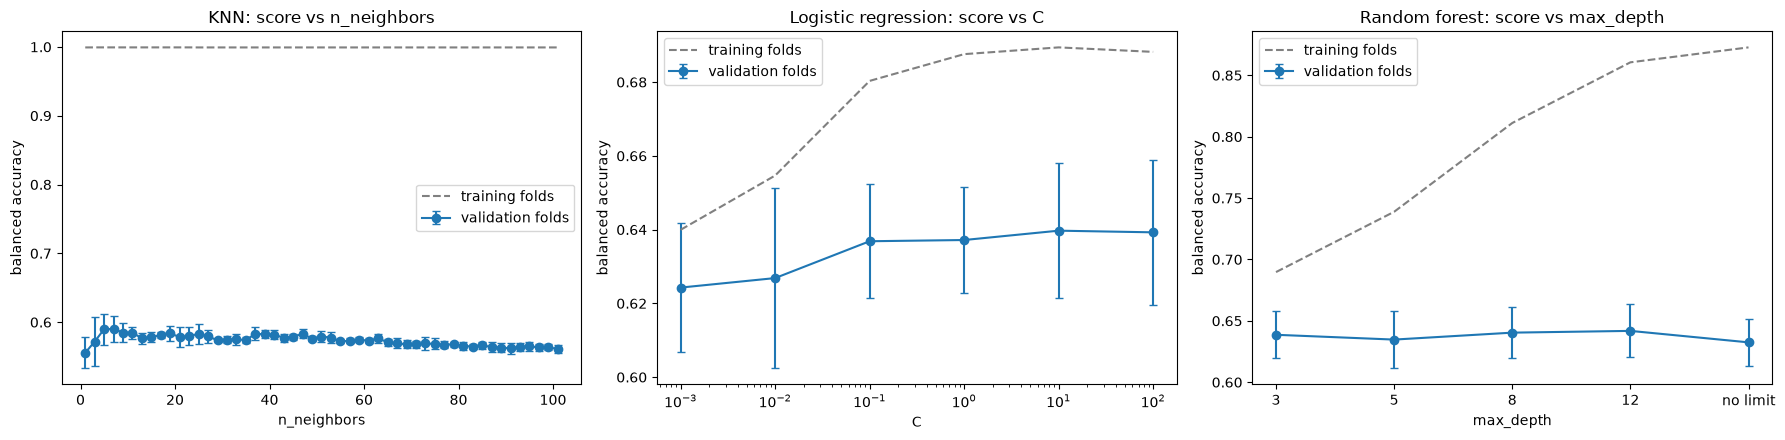

In [15]:
def as_text(values):
    # Hyperparameter values as text, so None / numbers can be compared safely.
    return values.map(lambda v: "None" if v is None or (isinstance(v, float) and np.isnan(v)) else str(v))

def plot_curve(ax, search, param, fixed, log=False, title=""):
    # Mean CV score (with spread over the 5 folds) against one hyperparameter, others fixed at their best value.
    res = pd.DataFrame(search.cv_results_)
    for p, v in fixed.items():
        res = res[as_text(res[f"param_{p}"]) == str(v)]
    x = res[f"param_{param}"].astype(float)
    ax.errorbar(x, res["mean_test_score"], yerr=res["std_test_score"], marker="o", capsize=3, label="validation folds")
    ax.plot(x, res["mean_train_score"], linestyle="--", color="grey", label="training folds")
    if log:
        ax.set_xscale("log")
    ax.set_xlabel(param.replace("model__", "")); ax.set_ylabel("balanced accuracy")
    ax.set_title(title); ax.legend()

knn, lr, rf = searches["KNN"], searches["Logistic regression"], searches["Random forest"]
fig, axes = plt.subplots(1, 3, figsize=(18, 4.5))
plot_curve(axes[0], knn, "model__n_neighbors", {"model__weights": knn.best_params_["model__weights"]},
           title="KNN: score vs n_neighbors")
plot_curve(axes[1], lr, "model__C", {"model__class_weight": lr.best_params_["model__class_weight"]},
           log=True, title="Logistic regression: score vs C")
rf_res = pd.DataFrame(rf.cv_results_)
rf_res = rf_res[(as_text(rf_res["param_model__min_samples_leaf"]) == str(rf.best_params_["model__min_samples_leaf"])) &
                (as_text(rf_res["param_model__class_weight"]) == str(rf.best_params_["model__class_weight"]))]
depth_labels = as_text(rf_res["param_model__max_depth"]).replace("None", "no limit")
axes[2].errorbar(depth_labels, rf_res["mean_test_score"], yerr=rf_res["std_test_score"], marker="o", capsize=3, label="validation folds")
axes[2].plot(depth_labels, rf_res["mean_train_score"], linestyle="--", color="grey", label="training folds")
axes[2].set_xlabel("max_depth"); axes[2].set_ylabel("balanced accuracy"); axes[2].legend()
axes[2].set_title("Random forest: score vs max_depth")
plt.tight_layout()
plt.show()

**How to read these plots.** The grey dashed line is the score on the folds the model was trained on. The blue line is the score on the held-out fold, with the spread over the five folds as error bars. A large gap between the two lines means the model memorises the training data (overfitting). Two low lines close together mean the model is too simple (underfitting).

For KNN the validation score peaks at about 0.59 with 5 to 9 neighbours and slowly drops to 0.56 with 101 neighbours. The training score is 1.0 everywhere because the best setting weighs neighbours by distance, and every training person is their own nearest neighbour. Unlike the other two models, KNN cannot give the smaller class more weight, so with more neighbours it drifts towards predicting "back in work".

For the logistic regression the validation score rises from 0.62 at `C = 0.001` (strong regularisation) to about 0.64 from `C = 0.1` on, and is then flat. The chosen `C = 10` (0.640) is not meaningfully better than `C = 0.1` (0.637). The gap with the training folds is about 0.05, which is mild overfitting.

For the random forest the validation score is flat (0.63 to 0.64) for every depth, while the training score climbs from 0.69 at depth 3 to 0.87 without a limit. Deeper trees only memorise the training data. The chosen depth 12 (0.642) is not better than depth 3 (0.639).

For all three models the differences between the best few settings are smaller than the spread over the folds (about ± 0.02), so we should not read much into the exact best value.

## Step 7: Evaluate once on the test set
Only now does every tuned model (refitted on the full training set by `GridSearchCV`) and the three baselines predict the test set.

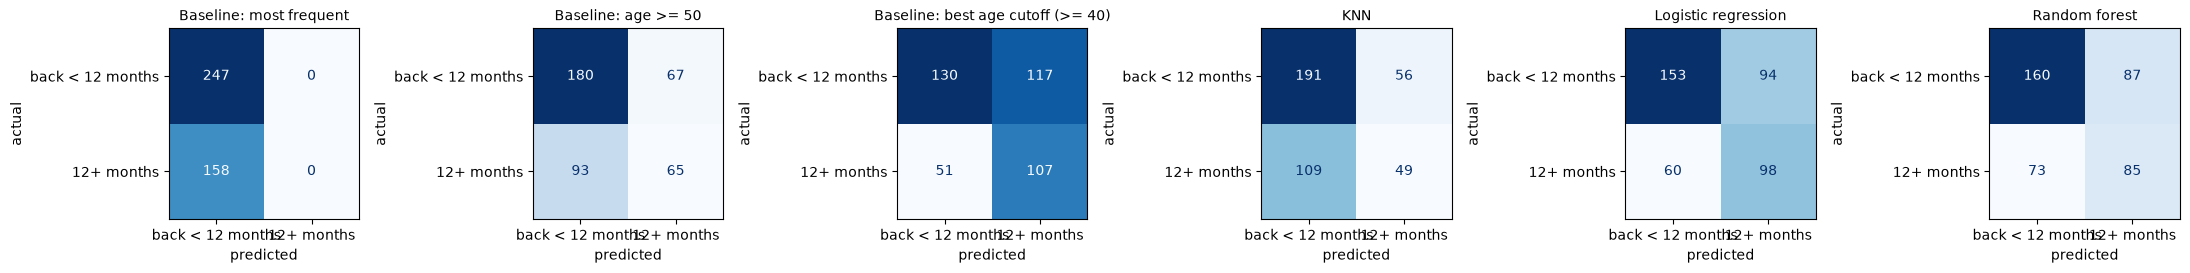

In [16]:
final_models = {name: model.fit(X_train, y_train) for name, model in baselines.items()}
final_models.update({name: s.best_estimator_ for name, s in searches.items()})

test_pred = {name: m.predict(X_test) for name, m in final_models.items()}

fig, axes = plt.subplots(1, len(test_pred), figsize=(22, 4))
for ax, (name, pred) in zip(axes, test_pred.items()):
    ConfusionMatrixDisplay(confusion_matrix(y_test, pred), display_labels=["back < 12 months", "12+ months"]).plot(
        ax=ax, colorbar=False, cmap="Blues")
    ax.set_title(name, fontsize=10)
    ax.set_xlabel("predicted"); ax.set_ylabel("actual")
plt.tight_layout()
plt.savefig(FIG_DIR / "confusion_matrices.png", dpi=120, bbox_inches="tight")
plt.show()

In [17]:
def scores(y_true, pred):
    return {"balanced accuracy": balanced_accuracy_score(y_true, pred),
            "precision": precision_score(y_true, pred, zero_division=0),
            "recall": recall_score(y_true, pred),
            "F1": f1_score(y_true, pred, zero_division=0)}

def cv_scores(name):
    # Mean and std of the CV balanced accuracy: from the grid search, or computed with the same folds.
    if name in searches:
        s = searches[name]
        return s.cv_results_["mean_test_score"][s.best_index_], s.cv_results_["std_test_score"][s.best_index_]
    res = cross_val_score(final_models[name], X_train, y_train, cv=folds, scoring=SCORING)
    return res.mean(), res.std()

# Train vs CV vs test balanced accuracy: the gaps tell us about over- and underfitting
gap_rows = []
for name, model in final_models.items():
    gap_rows.append({"model": name,
                     "train": balanced_accuracy_score(y_train, model.predict(X_train)),
                     "cross-validation": cv_scores(name)[0],
                     "test": balanced_accuracy_score(y_test, test_pred[name])})
pd.DataFrame(gap_rows).set_index("model").round(3)

,train,cross-validation,test
model,,,
Baseline: most frequent,0.500,0.500,0.500
Baseline: age >= 50,0.603,0.603,0.570
Baseline: best age cutoff (>= 40),0.609,0.609,0.602
KNN,0.999,0.590,0.542
Logistic regression,0.686,0.640,0.620
Random forest,0.854,0.642,0.593


In [18]:
# The required comparison table, baselines first
comparison = []
for name, pred in test_pred.items():
    if name in searches:
        params = {k.replace("model__", ""): v for k, v in searches[name].best_params_.items()}
    else:
        params = "-" if "most" in name else {"age_threshold": final_models[name].age_threshold}
    mean, std = cv_scores(name)
    row = {"model": name, "best hyperparameters": params, "CV balanced accuracy": f"{mean:.3f} ± {std:.3f}"}
    row.update({f"test {k}": round(v, 3) for k, v in scores(y_test, pred).items()})
    comparison.append(row)
comparison_table = pd.DataFrame(comparison)
comparison_table

,model,best hyperparameters,CV balanced accuracy,test balanced accuracy,test precision,test recall,test F1
0,Baseline: most frequent,-,0.500 ± 0.000,0.500,0.000,0.000,0.000
1,Baseline: age >= 50,{'age_threshold': 50},0.603 ± 0.020,0.570,0.492,0.411,0.448
2,Baseline: best age cutoff (>= 40),{'age_threshold': 40},0.609 ± 0.018,0.602,0.478,0.677,0.560
3,KNN,"{'n_neighbors': 7, 'weights': 'distance'}",0.590 ± 0.019,0.542,0.467,0.310,0.373
4,Logistic regression,"{'C': 10, 'class_weight': 'balanced'}",0.640 ± 0.018,0.620,0.510,0.620,0.560
5,Random forest,"{'class_weight': 'balanced', 'max_depth': 12, 'min_samples_leaf': 5}",0.642 ± 0.022,0.593,0.494,0.538,0.515


**What the gaps tell us** (numbers in the two tables above).

The logistic regression (train 0.69 / CV 0.64 / test 0.62) has a small gap. It overfits a little, and the test score lies about one standard deviation (± 0.018) below the CV score, so the test set roughly confirms the cross-validation.

The random forest (0.85 / 0.64 / 0.59) clearly overfits. It is 0.21 better on its training data than in cross-validation, and on the test set it drops another 0.05, more than two standard deviations below its CV score. It does worse on new people than cross-validation promised.

KNN (1.00 / 0.59 / 0.54) memorises the training data and is the weakest model. On the test set it is worse than both age rules.

Against the simple rules the picture is less comfortable than we hoped. The logistic regression clearly beats the rule we picked ourselves, 50 or older: 0.62 against 0.57 on the test set, and 62% of the long-term cases found against 41%. But the rule with the best cutoff, 40 or older, scores 0.602 on the test set. It even finds more of the long-term cases (68%), because it invites more people. In cross-validation the logistic regression is 0.031 ahead of that rule (0.640 against 0.609). That is more than the spread over the folds (± 0.018), but less than twice the spread. On the test set the lead is 0.018. So our best model is at most a little better than a rule a coach can apply without a computer. Step 9a compares the two at the same workload. The dummy finds nobody.

None of the models is strong. A balanced accuracy of 0.62 means that in both groups roughly four in ten people are classified wrongly. Background, previous job, work history and health only partly explain who stays without work.

## Step 8: Look at the errors
We continue with the model we would hand to UWV, chosen on cross-validation only, because choosing on the test set would be tuning on it. We take the best CV score, unless the logistic regression is within the spread over the folds of that score. In that case the models are equally good and we take the logistic regression, because a work coach can explain its prediction (step 9). Which job seekers does it get wrong? We cannot show individual cases (see *privacy* at the top), so we compare the average profile of the long-term cases the model *missed* with the ones it *found*, and then the scores per group.

In [19]:
best_cv_name = max(searches, key=lambda n: searches[n].best_score_)
(top_mean, top_std), (lr_mean, lr_std) = cv_scores(best_cv_name), cv_scores("Logistic regression")
if top_mean - lr_mean <= max(top_std, lr_std):
    best_name = "Logistic regression"
else:
    best_name = best_cv_name
best_model = final_models[best_name]
best_pred = test_pred[best_name]
print(f"Best CV balanced accuracy: {best_cv_name} ({top_mean:.3f} ± {top_std:.3f}); "
      f"logistic regression {lr_mean:.3f} ± {lr_std:.3f}")
print("Model we continue with:", best_name)

errors = info_test.copy()
errors["actual"] = y_test.to_numpy()
errors["predicted"] = best_pred
errors["result"] = np.select(
    [(errors.actual == 1) & (errors.predicted == 1), (errors.actual == 1) & (errors.predicted == 0),
     (errors.actual == 0) & (errors.predicted == 1)],
    ["correct: long-term", "MISSED (false negative)", "extra invite (false positive)"], default="correct: back in work")
print(errors["result"].value_counts().to_string())

# Average profile of the long-term cases: missed vs found (groups, never individuals)
long_term = X_test.assign(result=errors["result"].to_numpy())
long_term = long_term[long_term["result"].isin(["MISSED (false negative)", "correct: long-term"])]
profile = pd.DataFrame({
    "people": long_term.groupby("result").size(),
    "mean age": long_term.groupby("result")["age"].mean().round(1),
    "mean months looking for work before": long_term.groupby("result")["months_unemployed_before"].mean().round(1),
    "% temporary / on-call / temp agency": long_term.groupby("result")["contract"].apply(
        lambda s: s.isin(["temporary", "on-call", "temp agency"]).mean() * 100).round(0),
    "% higher education (hbo/wo)": long_term.groupby("result")["education"].apply(
        lambda s: s.isin(["hbo", "wo"]).mean() * 100).round(0),
    "% poor or moderate health": long_term.groupby("result")["health_self_rated"].apply(
        lambda s: s.le(2).mean() * 100).round(0),
    "% no job interview before": long_term.groupby("result")["contract"].apply(lambda s: s.isna().mean() * 100).round(0),
}).T
profile if (profile.loc["people"] >= MIN_GROUP).all() else print("A group has fewer than", MIN_GROUP, "people: not shown")

Best CV balanced accuracy: Random forest (0.642 ± 0.022); logistic regression 0.640 ± 0.018
Model we continue with: Logistic regression
result
correct: back in work            153
correct: long-term                98
extra invite (false positive)     94
MISSED (false negative)           60


result,MISSED (false negative),correct: long-term
people,60.0,98.0
mean age,38.8,49.9
mean months looking for work before,4.4,3.7
% temporary / on-call / temp agency,37.0,29.0
% higher education (hbo/wo),25.0,22.0
% poor or moderate health,5.0,27.0
% no job interview before,37.0,20.0


In [20]:
def group_report(frame, group_col, rows_label="test rows"):
    rows = []
    for group, g in frame.groupby(group_col, observed=True):
        if len(g) < MIN_GROUP:
            rows.append({"group": f"{group_col}: {group}", rows_label: f"< {MIN_GROUP}"})
            continue
        rows.append({"group": f"{group_col}: {group}", rows_label: len(g),
                     "long-term cases": int(g.actual.sum()),      # recall is a share of this number
                     "share long-term": round(g.actual.mean(), 2),
                     "recall": round(recall_score(g.actual, g.predicted, zero_division=0), 2),
                     "precision": round(precision_score(g.actual, g.predicted, zero_division=0), 2),
                     "missed (FN)": int(((g.actual == 1) & (g.predicted == 0)).sum())})
    return pd.DataFrame(rows)

subgroups = pd.concat([group_report(errors, c) for c in info.columns], ignore_index=True)
subgroups

,group,test rows,long-term cases,share long-term,recall,precision,missed (FN)
0,age band: 18-29,87,17.0,0.20,0.29,0.83,12.0
1,age band: 30-49,186,76.0,0.41,0.50,0.52,38.0
2,age band: 50-66,132,65.0,0.49,0.85,0.49,10.0
3,gender: female,201,82.0,0.41,0.77,0.56,19.0
4,gender: male,204,76.0,0.37,0.46,0.44,41.0
5,education: high,118,37.0,0.31,0.59,0.51,15.0
6,education: low,102,52.0,0.51,0.75,0.59,13.0
7,education: middle,177,66.0,0.37,0.56,0.46,29.0
8,education: other,< 10,NaN,NaN,NaN,NaN,NaN
9,origin: Dutch background,261,93.0,0.36,0.70,0.51,28.0


**Who does the model miss?** On the test set the logistic regression finds 98 of the 158 long-term cases and misses 60. The errors are not evenly spread.

Young people are missed most. Of the long-term cases aged 18-29 the model finds only 29% (5 of 17), for 30-49 it finds 50% and for 50-66 it finds 85%. The model has learned that age predicts long-term unemployment, so a young person who does get stuck looks like someone who will find work quickly. In absolute numbers the 30-49 group has the most missed people (38).

On this test set men are missed far more often than women: recall is 0.46 for men against 0.77 for women, while both groups are almost equally often long-term (37% and 41%). The model misses 41 men against 19 women. That is the largest gap between two big groups, so the next cell checks whether it holds on more data (it mostly does not), and 8d looks for the cause.

People with a long-standing disease are found almost always (0.91), people without one far less often (0.59). Recall is higher for lower-educated people (0.75) than for middle (0.56) and higher (0.59) education. People with a Dutch background are found more often (0.70) than first-generation (0.63) and second-generation migrants (0.44), but the migrant groups have only 27 and 18 long-term cases in the test set, so this is about a handful of people.

The profile of the missed cases confirms this. Compared with the long-term cases the model found, the missed ones are on average eleven years younger (39 against 50), more often had a flexible contract (37% against 29%), almost never reported poor or moderate health (5% against 27%), and more often had no Work and Schooling interview before the job loss (37% against 20%). The model relies on age and health. Long-term unemployment of young, healthy people on flexible contracts, and of people we know less about, is largely invisible to it.

**Is that a pattern or a handful of people?** Some groups in the test set are small. Recall for the youngest group is a share of only a few dozen long-term cases, so a few people more or less change the number a lot. To see whether the gaps hold, we repeat the check on the training set with cross-validation: every person is predicted by a model that was trained without them, and the training set is four times as large. The table shows both next to each other, with the number of long-term cases each recall is based on.

In [21]:
cv_pred = cross_val_predict(best_model, X_train, y_train, cv=folds)
errors_cv = info_train.copy()
errors_cv["actual"] = y_train.to_numpy()
errors_cv["predicted"] = cv_pred
subgroups_cv = pd.concat([group_report(errors_cv, c, rows_label="training rows") for c in info.columns], ignore_index=True)

side_by_side = pd.DataFrame({
    "group": subgroups["group"],
    "long-term cases (test)": subgroups["long-term cases"],
    "recall (test)": subgroups["recall"],
    "long-term cases (training)": subgroups_cv.set_index("group")["long-term cases"].reindex(subgroups["group"]).to_numpy(),
    "recall (training, CV)": subgroups_cv.set_index("group")["recall"].reindex(subgroups["group"]).to_numpy()})
side_by_side

,group,long-term cases (test),recall (test),long-term cases (training),"recall (training, CV)"
0,age band: 18-29,17.0,0.29,102,0.15
1,age band: 30-49,76.0,0.50,237,0.50
2,age band: 50-66,65.0,0.85,292,0.85
3,gender: female,82.0,0.77,317,0.62
4,gender: male,76.0,0.46,314,0.59
5,education: high,37.0,0.59,191,0.52
6,education: low,52.0,0.75,158,0.65
7,education: middle,66.0,0.56,267,0.64
8,education: other,NaN,NaN,15,0.60
9,origin: Dutch background,93.0,0.70,427,0.63


**What holds and what does not.**

The age gap holds, and it is larger on more data. Of the 102 young long-term cases in the training set the model finds 15%. For the 30-49 group it finds 50% and for 50-66 it finds 85%, the same as on the test set. Young people who get stuck are almost invisible to this model. That is the finding we are most sure of.

The gap between men and women mostly does not hold. On the test set it was 31 points (0.77 against 0.46). On the training set, with about 315 long-term cases in each group, it is 3 points (0.62 against 0.59). Most of what we saw on the test set is chance: it depends on which 405 job losses happened to land there. We look at the small difference that remains in 8d.

The other gaps shrink too. People with a long-standing disease are still found more often (0.79 against 0.59). Lower- and middle-educated people are found about as often (0.65 and 0.64), higher-educated people less (0.52). For origin the recall is 0.63 for a Dutch background, 0.69 for the first generation and 0.55 for the second generation, which stays the lowest, on 58 cases.

The lesson for us: a recall that is based on 17 or 18 long-term cases can be far off. From here on we only trust a gap between groups when it shows up in both columns.

### 8b. Fairness experiment: with or without migration background?
In our data, people who migrated to the Netherlands themselves are more often long-term unemployed (57% against 38%, see 2f). Should UWV's model use migration background? Using it could steer help to people who need it. But it is also exactly the kind of profiling the SyRI judgment (District Court of The Hague, 2020) and the childcare benefits scandal warned against. We test it with cross-validation on the training set (the test set stays untouched): the same model, once without and once with `origin` as a feature.

In [22]:
best_params = searches[best_name].best_params_

def cv_predict_with(numeric, categorical, frame):
    pipe = Pipeline([("prep", make_preprocessor(numeric, categorical)),
                     ("model", candidates[best_name][0])]).set_params(**best_params)
    return cross_val_predict(pipe, frame, y_train, cv=folds)

def recall_per_group(pred, group_col):
    out = {}
    for group in info_train[group_col].dropna().unique():
        mask = (info_train[group_col] == group).to_numpy()
        if mask.sum() >= MIN_GROUP:
            out[f"recall: {group}"] = round(recall_score(y_train[mask], pred[mask], zero_division=0), 2)
    return out

X_train_origin = X_train.assign(origin=info_train["origin"])
rows = []
for label, extra in [("without origin", []), ("with origin", ["origin"])]:
    pred = cv_predict_with(NUMERIC, CATEGORICAL + extra, X_train_origin)
    rows.append({"model": f"{best_name} {label}",
                 "CV balanced accuracy": round(balanced_accuracy_score(y_train, pred), 3),
                 **recall_per_group(pred, "origin")})
pd.DataFrame(rows)

,model,CV balanced accuracy,recall: first generation migrant,recall: Dutch background,recall: second generation migrant
0,Logistic regression without origin,0.640,0.69,0.63,0.55
1,Logistic regression with origin,0.633,0.87,0.60,0.57


In [23]:
# Proxy check: can the features we DID keep guess someone's migration background?
known = info_train["origin"].notna()
origin_target = (info_train.loc[known, "origin"] != "Dutch background").astype(int)
proxy = Pipeline([("prep", make_preprocessor()), ("model", LogisticRegression(max_iter=2000))])
auc = cross_val_score(proxy, X_train[known], origin_target, cv=StratifiedGroupKFold(5, shuffle=True, random_state=RANDOM_STATE),
                      groups=groups_train[known], scoring="roc_auc").mean()
print(f"ROC-AUC for guessing migration background from our model features: {auc:.2f} (0.5 = impossible to guess)")

ROC-AUC for guessing migration background from our model features: 0.68 (0.5 = impossible to guess)


**What we conclude and do.** Adding migration background does not improve the model: balanced accuracy 0.633 with against 0.640 without, a difference well within the spread over the folds. It does move help around: recall for first-generation migrants rises from 0.69 to 0.87, while it drops a little for people with a Dutch background (0.63 → 0.60). So using origin would not make the model better. It would only score people higher because of where they were born. We keep migration background out of the model, as decided beforehand.

The proxy check shows that removing the column does not make the model blind to origin: the other features predict migration background with a ROC-AUC of 0.68 (0.5 would mean no information). So we do not rely on leaving the column out: the recall per origin group in step 8 is the real safeguard, and it has to be repeated whenever the model is retrained. The second generation, which the model finds least often on the test set (0.44, also lowest in cross-validation: 0.55), is the group to watch.

### 8c. Health: does it belong in the model?
Health is the other sensitive group of features. It is a *special category of personal data* under the GDPR, and a work coach may only use it with good reason. It can also help people with health problems get early support. We compare the same model with and without the three health features, with cross-validation on the training set.

In [24]:
rows = []
for label, num, cat in [("with health", NUMERIC, CATEGORICAL),
                        ("without health", [c for c in NUMERIC if c not in HEALTH], [c for c in CATEGORICAL if c not in HEALTH])]:
    pred = cv_predict_with(num, cat, X_train)
    rows.append({"model": f"{best_name} {label}",
                 "CV balanced accuracy": round(balanced_accuracy_score(y_train, pred), 3),
                 "CV recall": round(recall_score(y_train, pred), 3),
                 **recall_per_group(pred, "long-standing disease")})
pd.DataFrame(rows)

,model,CV balanced accuracy,CV recall,recall: no,recall: yes
0,Logistic regression with health,0.640,0.607,0.59,0.79
1,Logistic regression without health,0.628,0.594,0.61,0.68


**What we conclude and do.** The three health features add little overall: balanced accuracy 0.640 with against 0.628 without, less than the spread over the folds (± 0.018). But they matter for one group: the model finds 79% of the long-term cases among people with a long-standing disease *with* health, against 68% *without*. People with a long-standing disease are more often long-term unemployed (51% against 38%), so here health information steers early help to people who need it.

**We keep health in the model, under two conditions.** Answering the health questions must be voluntary for the job seeker, and declining may never lower their chance of an invitation: UWV should then score the person both with and without a health answer and use the *higher* risk. In our data a missing health answer means "did not take part in the survey"; at UWV it would mean "did not want to say", which the model has never seen. See `ETHICS.md`.

### 8d. Men and women: where does the difference come from?
On the test set the model finds far fewer of the long-term unemployed men than women. On the training set the gap is small, but it is still there, and both groups are about as often long-term unemployed. We look at three things, all on the training set with cross-validation:

1. Does the gap disappear when we take gender out of the model? If it does, the model is scoring on gender itself.
2. How much weight does the logistic regression give to gender?
3. Do men and women in our data differ on other features the model uses, such as age, contract hours and income? Then the gap can come in through those features even without the gender column.

In [25]:
genders = [g for g in ["male", "female"] if (info_train["gender"] == g).sum() >= MIN_GROUP]
rows = []
for label, cat in [("with gender", CATEGORICAL), ("without gender", [c for c in CATEGORICAL if c != "gender"])]:
    pred = cv_predict_with(NUMERIC, cat, X_train)
    row = {"model": f"{best_name} {label}",
           "CV balanced accuracy": round(balanced_accuracy_score(y_train, pred), 3),
           **recall_per_group(pred, "gender")}
    for g in genders:
        row[f"share invited: {g}"] = round(pred[(info_train["gender"] == g).to_numpy()].mean(), 2)
    rows.append(row)
display(pd.DataFrame(rows))

# 2. The weight the tuned logistic regression gives to gender
lr_fit = searches["Logistic regression"].best_estimator_
lr_coefs = pd.Series(lr_fit.named_steps["model"].coef_[0], index=lr_fit.named_steps["prep"].get_feature_names_out())
print("Coefficients for gender (positive = higher predicted risk):")
print(lr_coefs[lr_coefs.index.str.contains("gender")].round(2).to_string())

# 3. Group averages of men and women in the training set (averages only, never individual rows)
by_gender = X_train[X_train["gender"].isin(genders)].assign(long_term=y_train).groupby("gender")
pd.DataFrame({"job losses": by_gender.size(),
              "share long-term": by_gender["long_term"].mean().round(2),
              "mean age": by_gender["age"].mean().round(1),
              "mean contract hours": by_gender["contract_hours"].mean().round(1),
              "mean net income": by_gender["net_income"].mean().round(0),
              "% long-standing disease": by_gender["longstanding_disease"].apply(lambda s: (s == "yes").mean() * 100).round(0),
              "% no job interview before": by_gender["contract"].apply(lambda s: s.isna().mean() * 100).round(0)}).T

,model,CV balanced accuracy,recall: female,recall: male,share invited: male,share invited: female
0,Logistic regression with gender,0.640,0.62,0.59,0.39,0.48
1,Logistic regression without gender,0.634,0.59,0.61,0.43,0.45


Coefficients for gender (positive = higher predicted risk):
cat__gender_female    0.11
cat__gender_male     -0.14


gender,female,male
job losses,762.00,852.00
share long-term,0.42,0.37
mean age,40.70,42.90
mean contract hours,27.80,35.80
mean net income,1370.00,1816.00
% long-standing disease,19.00,15.00
% no job interview before,27.00,34.00


**What we conclude.** The difference between men and women is small, and three things explain it.

Gender itself gets a small weight in the model: +0.11 for women and -0.14 for men. For comparison, a long-standing disease gets +0.72 (step 9). With gender in the model it invites 48% of the women and 39% of the men. Without gender that becomes 45% and 43%, and recall is almost equal (0.59 for women, 0.61 for men).

The rest comes in through other features. The women in our data worked fewer hours in the job they lost (28 against 36 a week) and earned less (1,370 against 1,816 euros net a month), and a lower income raises the predicted risk. They are also in fact somewhat more often long-term unemployed (42% against 37%), so inviting women a little more often is not wrong in itself.

Taking gender out costs 0.006 balanced accuracy (0.640 against 0.634), far less than the spread over the folds. In 8b we set a rule for migration background: a feature that scores people on who they are, and does not clearly improve the model, should not be in it. By that same rule gender does not earn its place either. We did not take it out in this notebook, because we found this at the end and it changes every number from step 6 on. It is the first change we would make in a next version, and the table above shows what it would do.

## Step 9: Recommend

### 9a. Choosing the decision threshold
By default a model invites someone when its probability of long-term unemployment is at least 0.5. Because a missed person (false negative) is worse than an extra conversation, UWV can lower that threshold. We choose it with cross-validated probabilities on the **training set**, so the test set still plays no role in the choice.

In [26]:
cv_proba = cross_val_predict(best_model, X_train, y_train, cv=folds, method="predict_proba")[:, 1]
threshold_rows = []
for t in np.arange(0.20, 0.71, 0.05):
    pred = (cv_proba >= t).astype(int)
    threshold_rows.append({"threshold": round(t, 2),
                           "recall (long-term found)": round(recall_score(y_train, pred), 3),
                           "precision (invites that were needed)": round(precision_score(y_train, pred, zero_division=0), 3),
                           "share of people invited": round(pred.mean(), 3),
                           "balanced accuracy": round(balanced_accuracy_score(y_train, pred), 3)})
threshold_table = pd.DataFrame(threshold_rows)
display(threshold_table)

TARGET_RECALL = 0.80
reachable = threshold_table[threshold_table["recall (long-term found)"] >= TARGET_RECALL]
chosen = reachable["threshold"].max() if len(reachable) else threshold_table["threshold"].min()
print(f"Highest threshold that still finds at least {TARGET_RECALL:.0%} of the long-term cases (CV): {chosen}")

,threshold,recall (long-term found),precision (invites that were needed),share of people invited,balanced accuracy
0,0.20,0.954,0.405,0.922,0.526
1,0.25,0.918,0.418,0.857,0.549
2,0.30,0.883,0.439,0.786,0.579
3,0.35,0.827,0.464,0.696,0.607
4,0.40,0.765,0.486,0.616,0.623
5,0.45,0.672,0.505,0.520,0.624
6,0.50,0.607,0.543,0.437,0.640
7,0.55,0.534,0.575,0.363,0.640
8,0.60,0.456,0.593,0.301,0.627
9,0.65,0.374,0.621,0.235,0.614


Highest threshold that still finds at least 80% of the long-term cases (CV): 0.35


In [27]:
test_proba = best_model.predict_proba(X_test)[:, 1]
final = pd.DataFrame([{"threshold": 0.5, **scores(y_test, (test_proba >= 0.5).astype(int))},
                      {"threshold": chosen, **scores(y_test, (test_proba >= chosen).astype(int))}]).round(3)
final["share invited"] = [round((test_proba >= 0.5).mean(), 3), round((test_proba >= chosen).mean(), 3)]
print(best_name, "on the test set at both thresholds:")
final

Logistic regression on the test set at both thresholds:


,threshold,balanced accuracy,precision,recall,F1,share invited
0,0.50,0.620,0.510,0.620,0.560,0.474
1,0.35,0.566,0.433,0.804,0.563,0.723


**Same workload, who finds more people?** A coach has a fixed number of early conversations. So the fair question is not which method scores higher, but which one finds more long-term cases when both invite the same share of people. For each age rule we look up which share of job seekers it invites, set the model's threshold so that it invites the same share (on the cross-validated training predictions, not on the test set), and compare both on the test set.

In [28]:
rows = []
for name in [n for n in baselines if "age" in n]:
    share = final_models[name].predict(X_train).mean()       # share of job seekers this age rule invites
    t = np.quantile(cv_proba, 1 - share)                     # model threshold that invites the same share
    for label, pred in [(name, test_pred[name]),
                        (f"{best_name} at threshold {t:.2f}", (test_proba >= t).astype(int))]:
        rows.append({"who decides": label,
                     "share invited": round(pred.mean(), 3),
                     "long-term cases found": int(((y_test == 1) & (pred == 1)).sum()),
                     **{k: round(v, 3) for k, v in scores(y_test, pred).items()}})
pd.DataFrame(rows)

,who decides,share invited,long-term cases found,balanced accuracy,precision,recall,F1
0,Baseline: age >= 50,0.326,65,0.570,0.492,0.411,0.448
1,Logistic regression at threshold 0.57,0.370,78,0.601,0.520,0.494,0.506
2,Baseline: best age cutoff (>= 40),0.553,107,0.602,0.478,0.677,0.560
3,Logistic regression at threshold 0.43,0.598,114,0.602,0.471,0.722,0.570


**What this shows.** Against "50 or older" the model is better at about the same workload. The rule invites 33% of the job seekers and finds 65 of the 158 long-term cases. The model, set to invite the same share on the training set, invites 37% on the test set and finds 78, with slightly better precision (0.52 against 0.49).

Against "40 or older" there is no real difference. The rule invites 55% and finds 107. The model invites 60% and finds 114. That is seven more long-term cases for 18 more invitations, and the balanced accuracy is 0.602 for both.

So how much the model adds depends on how many people UWV can see. With room for about a third of the job seekers, the model picks better than age alone. With room for more than half, a coach who invites everyone aged 40 or older does just as well. What the model still offers then is a different selection, not a better one. It can invite a 32-year-old with a long-standing disease, which an age rule never does, and its score can follow UWV's capacity in small steps.

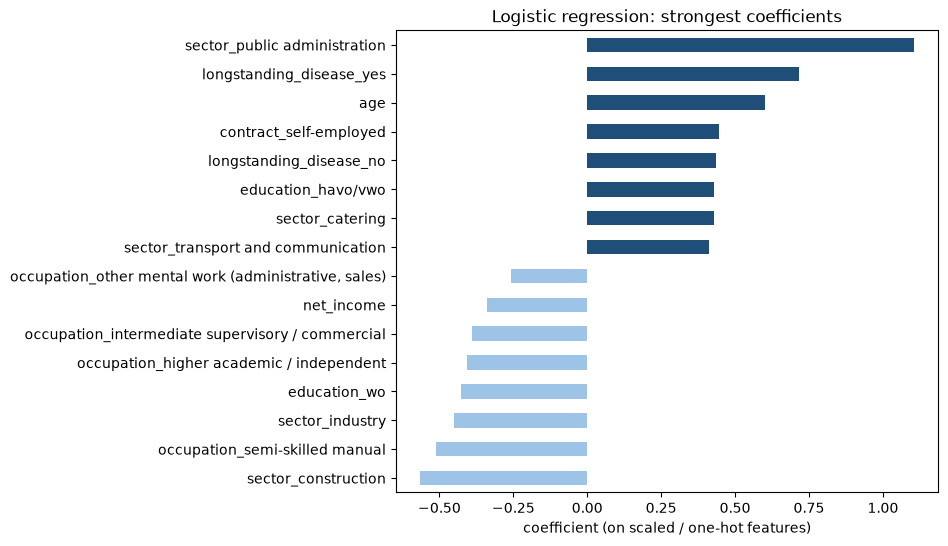

In [29]:
# What does the logistic regression look at? (positive = higher chance of long-term unemployment)
lr_model = searches["Logistic regression"].best_estimator_
names = lr_model.named_steps["prep"].get_feature_names_out()
coefs = pd.Series(lr_model.named_steps["model"].coef_[0], index=names)
# Only show columns that at least 30 people in the training set have: a coefficient for a
# handful of people is noise, not an explanation (and would describe very small groups).
Xt = lr_model.named_steps["prep"].transform(X_train)
people = pd.Series(np.asarray((Xt != 0).sum(axis=0)).ravel(), index=names)
coefs = coefs[people >= 30]
coefs.index = coefs.index.str.replace("num__", "").str.replace("cat__", "")
# The 'missing' columns are left out of the chart: someone without a health or job interview is missing on
# all those questions at once, so these columns overlap almost completely and their coefficients cancel
# each other out (one large positive, one large negative). They say "no survey answer", not something about the person.
coefs = coefs[~coefs.index.str.contains("missing")]
top = pd.concat([coefs.nlargest(8), coefs.nsmallest(8)]).sort_values()
top.plot.barh(figsize=(7, 6), color=np.where(top > 0, "#1f4e79", "#9dc3e6"))
plt.title("Logistic regression: strongest coefficients")
plt.xlabel("coefficient (on scaled / one-hot features)")
plt.savefig(FIG_DIR / "coefficients.png", dpi=120, bbox_inches="tight")
plt.show()

In [30]:
# A data-driven summary of the comparison, so the recommendation below rests on these numbers
ranking = sorted(searches, key=lambda n: searches[n].best_score_, reverse=True)
best_mean, best_std = cv_scores(ranking[0])
for name in ranking[1:]:
    mean, std = cv_scores(name)
    verdict = "smaller" if best_mean - mean < max(best_std, std) else "larger"
    print(f"{ranking[0]} vs {name}: CV difference {best_mean - mean:.3f}, "
          f"which is {verdict} than the spread over the folds (± {max(best_std, std):.3f})")
age_rule = balanced_accuracy_score(y_test, test_pred["Baseline: age >= 50"])
print(f"Test balanced accuracy: {best_name} (recommended) {balanced_accuracy_score(y_test, best_pred):.3f} "
      f"vs age rule {age_rule:.3f} vs dummy 0.500")
# The lower threshold buys recall with balanced accuracy: say so next to the same baseline
at_chosen = balanced_accuracy_score(y_test, (test_proba >= chosen).astype(int))
print(f"Test balanced accuracy of {best_name} at threshold {chosen}: {at_chosen:.3f} (age rule {age_rule:.3f})")

Random forest vs Logistic regression: CV difference 0.002, which is smaller than the spread over the folds (± 0.022)
Random forest vs KNN: CV difference 0.052, which is larger than the spread over the folds (± 0.022)
Test balanced accuracy: Logistic regression (recommended) 0.620 vs age rule 0.570 vs dummy 0.500
Test balanced accuracy of Logistic regression at threshold 0.35: 0.566 (age rule 0.570)


**Reading the coefficients** (chart above). Dark bars push the predicted risk up, light bars push it down. The coefficients of one question must be read relative to its other answers, and only answers that at least 30 people in the training set gave are shown.

Age raises the risk: older job seekers are more often still without work after a year. A long-standing disease raises it too. *Yes* (0.72) is higher than *no* (0.43), and both are positive because they are compared with the third answer, *no health interview*, which is left out of the chart. People from public administration, catering and transport have a higher risk, people from construction and industry a lower one. Higher academic, supervisory and administrative occupations and a university degree (wo) lower the risk, and so does semi-skilled manual work. Self-employed people have a higher risk. A higher net income in the last job lowers it.

This is what a work coach could tell a job seeker: *"you are invited early mainly because of your age and because people from your sector often need longer to find work"*. KNN or a random forest cannot give that explanation.

### 9b. Our recommendation to UWV

**Of the three models we recommend the logistic regression, as support for the work coach and not as a decision-maker. We also have to say that it adds little to a simple age rule.**

Why this model? In cross-validation it is as good as the random forest (0.640 ± 0.018 against 0.642 ± 0.022, a difference of 0.002 that is far below the spread over the folds) and clearly better than KNN (0.590). We decided beforehand that when models are equally good, we take the one a work coach can explain. It also overfits much less than the forest (0.69 on its own training data against 0.85) and holds up better on the test set (0.620 against 0.593).

How much better is it than no model? It clearly beats inviting nobody (0.50) and the rule "50 or older" (0.57 on the test set). Against the best age rule, "40 or older", the lead is small: 0.640 against 0.609 in cross-validation and 0.620 against 0.602 on the test set. At the same workload the two find about the same number of people (9a). A model with 22 features, three of them about health, does about as well as one question about age. That is the most honest summary of this notebook.

Which threshold? At the default threshold of 0.5 the model invites 47% of the job seekers on the test set and finds 62% of the long-term cases. At 0.35, the highest threshold that still finds 80% in cross-validation, it finds 80% but invites 72%, and precision drops to 0.43. Because a missed person is the worse mistake, 0.35 is the setting to use if UWV has the capacity to see about seven in ten people early, and 0.5 if it does not. That is a capacity decision for UWV, and the table in 9a shows what each choice costs. One warning belongs with it. At 0.35 the balanced accuracy on the test set drops to 0.566, below both age rules. At that setting the model finds more people mainly because it invites more people, not because it chooses better.

Is it good enough? Not to decide on its own. A balanced accuracy of 0.62 means that in both groups roughly four in ten people are classified wrongly. And the mistakes fall unevenly. The model finds only 15% to 29% of the young people who become long-term unemployed, and it more often misses people we have little information about. The large gap between men and women on the test set did not hold up on more data (step 8). Three rules follow from that.

1. The model may only add people to the early-invitation list. A low score must never mean less help, and a work coach can always invite someone. That applies most to young people and people whose job history is unknown, because the model often misses them.
2. It must never be used for obligations, sanctions or fraud detection. UWV's own research shows the conversation helps, and research at Leiden University (2024) found that imposing an obligation to search more broadly backfired.
3. Before any real use it must be retrained on recent UWV data of actual WW claimants, without gender as a feature (8d), and the check per group in step 8 must be repeated every time.

One more limit: the model predicts who is at risk, not who is helped by a conversation. UWV's evaluation found that conversations alone mostly helped people with a medium chance of work, and that people with the lowest chances need heavier help such as training (UWV, 2022). The first conversation is where a coach decides on that help, so an early invitation still matters, but the score does not say what will work for someone.

**Not comparable to UWV's "70% correct".** The Werkverkenner predicts for WW claimants with a questionnaire about attitude and job search, and reports accuracy (UWV, 2018). We predict for LISS panel members who lost their job, from background, previous job, work history and health, and report balanced accuracy. Our numbers say nothing about whether the Werkverkenner is better or worse. What they do say about a model of this kind is in 9c.


### 9c. What does this say about a model like the Werkverkenner?
Our project is also a check: how well can a model sort job seekers at intake at all? UWV reports that the Werkverkenner is right for about 70% of people (UWV, 2018). That number is plain accuracy, so we put the accuracy of our models and of the simple rules next to each other on the test set. Remember that most people are back in work within a year, so "predict that everyone finds work" is already right for a majority without knowing anything about anyone.

In [31]:
rows = []
for name, pred in test_pred.items():
    rows.append({"model": name,
                 "accuracy (share predicted right)": round(accuracy_score(y_test, pred), 3),
                 "balanced accuracy": round(balanced_accuracy_score(y_test, pred), 3),
                 "recall (long-term found)": round(recall_score(y_test, pred), 3)})
pd.DataFrame(rows).set_index("model")

,accuracy (share predicted right),balanced accuracy,recall (long-term found)
model,,,
Baseline: most frequent,0.610,0.500,0.000
Baseline: age >= 50,0.605,0.570,0.411
Baseline: best age cutoff (>= 40),0.585,0.602,0.677
KNN,0.593,0.542,0.310
Logistic regression,0.620,0.620,0.620
Random forest,0.605,0.593,0.538


**What we take from this.** On the test set, predicting "back in work" for everyone is right for 61% of the people. Our best model is right for 62%. Measured in plain accuracy, a model that looks at 22 features is one percentage point better than knowing nothing. The difference only shows in balanced accuracy and recall: the dummy finds none of the people who need help, and the model finds 62% of them.

That matters for how to read UWV's 70%. Seventy percent correct sounds good, but it only means something next to the share you get right by predicting the same for everyone. We could not find that share for the Werkverkenner in the UWV publications we used. If about six in ten claimants are back at work within a year, as in our data, 70% correct would be a modest gain over no model. We cannot say more than that, because our population and features are different. The Werkverkenner uses a questionnaire about job search and attitude that we do not have, and it may well do better than our model.

What our numbers do suggest is a ceiling. With what is known about a person at intake (age, household, education, the job they lost, their health), it is hard to predict who is still without work a year later. Three different kinds of model end up between 0.59 and 0.64 in cross-validation, and one question about age gets to 0.61. A large part of what decides the outcome is not in the data: the job market in that region and year, someone's network, motivation and luck.

Is it then realistic and ethical to sort people this way? We think it can be defended under three conditions, and all three follow from this notebook. The score may only add help, because the errors are too frequent to let it take help away. The errors per group have to be published, because ours fall mostly on young people and a single accuracy number hides that. And the alternative has to be named honestly. UWV cannot see everyone in the first weeks, so someone or something has to choose. A weak model that is checked per group and that a coach can overrule is better than one that is not checked. But it is not much better than a simple rule, and it should not be presented as more than that.

## Step 10: Use it
A new, **made-up** job seeker at UWV intake (not a person from the data). Change the values to try other cases; the category names must be written exactly as in step 2c. The last lines of the output show which of this person's answers push the score up or down most. That is the explanation a work coach could give.

In [32]:
new_case = pd.DataFrame([{
    "age": 58,
    "household_size": 1,
    "children_at_home": 0,
    "net_income": 1900,                  # euros per month in the last job
    "months_unemployed_before": 0,       # in the 36 months before the job loss
    "months_in_panel_before": 36,        # at UWV the full history is known
    "contract_hours": 32,
    "years_with_employer": 12,
    "health_self_rated": 2,              # 1 poor .. 5 excellent
    "health_hinders": 3,                 # 1 not at all .. 5 very much
    "gender": "female",
    "education": "mbo",
    "partner": "no",
    "domestic_situation": "single",
    "urbanity": "slightly urban",
    "contract": "temporary",
    "organisation": "private",
    "sector": "retail",
    "occupation": "other mental work (administrative, sales)",
    "supervisor": "no",
    "firm_size": "10-49",
    "longstanding_disease": "yes",
}])[FEATURES]

probability = best_model.predict_proba(new_case)[0, 1]
print(f"Model: {best_name}, threshold {chosen}")
print(f"Probability of still being without work after 12 months: {probability:.0%}")
print("Advice:", "invite early for a face-to-face conversation" if probability >= chosen
      else "start with online services; first conversation in the seventh month, unless the coach invites earlier")

# Why this score? For a logistic regression every feature adds (coefficient x value) to the score.
# Numbers are scaled, so their value means "compared with the average job seeker in the training set".
if best_name == "Logistic regression":
    prep, clf = best_model.named_steps["prep"], best_model.named_steps["model"]
    row = prep.transform(new_case)
    row = row.toarray() if hasattr(row, "toarray") else np.asarray(row)
    contribution = pd.Series(row.ravel() * clf.coef_[0], index=prep.get_feature_names_out())
    contribution.index = contribution.index.str.replace("num__", "").str.replace("cat__", "")
    # Leave out the "was missing" columns: they only say that an answer was given, not something about the person
    contribution = contribution[(contribution != 0) & ~contribution.index.str.contains("missing")]
    print("\nWhat a work coach could tell this person:")
    print("Raises the risk most: ", ", ".join(f"{k} ({v:+.2f})" for k, v in contribution.nlargest(3).items()))
    print("Lowers the risk most: ", ", ".join(f"{k} ({v:+.2f})" for k, v in contribution.nsmallest(3).items()))

Model: Logistic regression, threshold 0.35
Probability of still being without work after 12 months: 82%
Advice: invite early for a face-to-face conversation

What a work coach could tell this person:
Raises the risk most:  age (+0.75), longstanding_disease_yes (+0.72), years_with_employer (+0.27)
Lowers the risk most:  occupation_other mental work (administrative, sales) (-0.26), household_size (-0.16), net_income (-0.12)


**Reading the output.** This made-up job seeker gets 82%, far above both thresholds, so she is invited early. The last two lines are what makes the logistic regression usable for a coach. Her age and her long-standing disease raise the score most, followed by twelve years with the same employer. Her administrative occupation, living alone and an income a little above average pull it down. A coach can check these reasons against what they hear in the conversation, and disagree with the score.